# 04 — NLP: Gemini-Assisted Review Labeling and Demand Signals

Weak supervision using Gemini Flash labels, aggregated into zone-level demand features — works for any cuisine concept.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

## Sample Reviews — Any Cuisine


In [2]:
# Reviews span many cuisine types to demonstrate generality
sample_reviews = [
    "Amazing healthy Indian lunch bowl — fresh and light, will return.",
    "Great tonkotsu ramen, rich broth, came back twice this week.",
    "Authentic Korean BBQ with top-quality bulgogi and kimchi.",
    "Best tacos al pastor in the neighborhood, super fresh.",
    "Mediterranean bowls are filling but could use more variety.",
    "Average burger, nothing special, would not recommend.",
    "Incredible Ethiopian injera platter — generous portions.",
    "Solid vegan wrap but the salad bar is a bit sparse.",
    "Dim sum was mediocre, har gow skin too thick.",
    "Fresh smoothie bowls, acai is amazing, staff friendly.",
    "Overpriced Italian pasta, nothing you cannot get elsewhere.",
    "Healthy Indian dosa was excellent — gluten-free and filling.",
]
print(f"{len(sample_reviews)} sample reviews")

12 sample reviews


## Gemini Label Sample (loaded from processed labels)


In [3]:
from src.nlp.gemini_labels import build_label_prompt
from src.utils.taxonomy import all_known_subtypes

subtypes = all_known_subtypes()
print(f"Total supported subtypes: {len(subtypes)}")
print(subtypes)

_base = Path("..").resolve()
labels_full = pd.read_csv(_base / "data/processed/gemini_labels_full.csv")
label_df = labels_full[["review_text","sentiment","concept_subtype","confidence"]].dropna(subset=["review_text"]).head(len(sample_reviews)).copy()
label_df["review_id"] = range(len(label_df))
display(label_df[["review_id","sentiment","concept_subtype","confidence","review_text"]])


Total supported subtypes: 24
('salad_bowls', 'mediterranean_bowls', 'healthy_indian', 'vegan_grab_and_go', 'protein_forward_lunch', 'mexican', 'chinese', 'japanese', 'korean', 'thai', 'italian', 'greek', 'middle_eastern', 'caribbean', 'ethiopian', 'west_african', 'american_comfort', 'burgers', 'pizza', 'seafood', 'ramen', 'dim_sum', 'bakery_cafe', 'smoothie_juice')


,review_id,sentiment,concept_subtype,confidence,review_text
0,0,positive,other,1.0,yummy food and friendly service. available at ...
1,1,positive,street_food,1.0,This is definitely My favorite street cart! De...
2,2,positive,other,1.0,Delicious food. We got a lamb gyro plate that ...
3,3,positive,street_food,1.0,"This place is very unassuming. At first, you t..."
4,4,positive,other,1.0,Servers bring warmth alongside their many menu...
5,5,positive,other,1.0,I can't believe how good that was. All staff m...
6,6,positive,other,1.0,The dishes we selected showed creativity and s...
7,7,positive,middle_eastern,0.5,The Naya Roll was so Good Especially The Wrap....
8,8,positive,fast_casual,0.5,Solid casual dining option and I would recomme...
9,9,positive,fast_casual,0.8,This is just like CAVA in OC and LA so if you'...


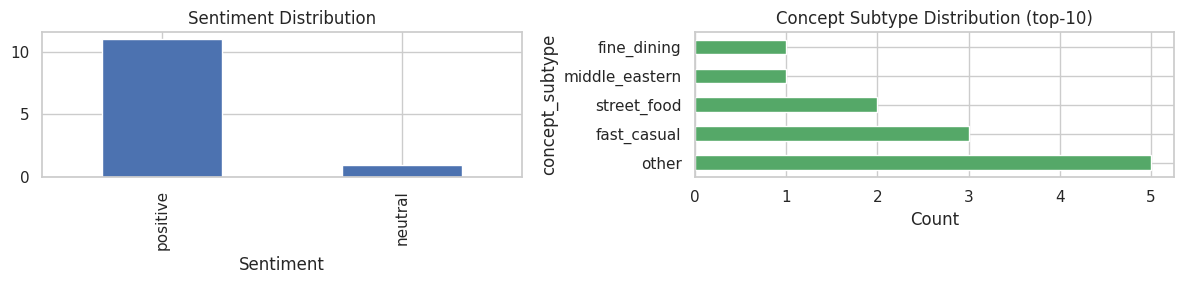

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

label_df["sentiment"].value_counts().plot.bar(
    ax=axes[0], color="#4C72B0", edgecolor="white"
)
axes[0].set_title("Sentiment Distribution")
axes[0].set_xlabel("Sentiment")

label_df["concept_subtype"].value_counts().head(10).plot.barh(
    ax=axes[1], color="#55A868", edgecolor="white"
)
axes[1].set_title("Concept Subtype Distribution (top-10)")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

## Subtype Classification (keyword-based)


In [5]:
from src.nlp.subtype_classifier import batch_classify

classified = batch_classify(sample_reviews)
comp_df = pd.DataFrame(
    {
        "review": sample_reviews,
        "gemini_label": label_df["concept_subtype"].values,
        "keyword_label": classified,
    }
)
comp_df["match"] = comp_df["gemini_label"] == comp_df["keyword_label"]
display(comp_df)
print(f"Agreement rate: {comp_df['match'].mean():.0%}")

,review,gemini_label,keyword_label,match
0,Amazing healthy Indian lunch bowl — fresh and ...,other,healthy_indian,False
1,"Great tonkotsu ramen, rich broth, came back tw...",street_food,ramen,False
2,Authentic Korean BBQ with top-quality bulgogi ...,other,korean,False
3,"Best tacos al pastor in the neighborhood, supe...",street_food,mexican,False
4,Mediterranean bowls are filling but could use ...,other,mediterranean_bowls,False
5,"Average burger, nothing special, would not rec...",other,burgers,False
6,Incredible Ethiopian injera platter — generous...,other,ethiopian,False
7,Solid vegan wrap but the salad bar is a bit sp...,middle_eastern,vegan_grab_and_go,False
8,"Dim sum was mediocre, har gow skin too thick.",fast_casual,dim_sum,False
9,"Fresh smoothie bowls, acai is amazing, staff f...",fast_casual,smoothie_juice,False


Agreement rate: 0%


## Review Aggregation into Zone Features


In [6]:
from src.nlp.review_aggregates import aggregate_review_labels

rng = np.random.default_rng(42)
zones = ["bk-tandon", "mn-columbia", "qn-astoria", "bx-fordham", "si-st-george"]
label_df["zone_id"] = rng.choice(zones, size=len(label_df))
label_df["time_key"] = rng.choice([2022, 2023, 2024], size=len(label_df))

agg = aggregate_review_labels(label_df)
print("Aggregated zone-time features:")
display(agg)

Aggregated zone-time features:


,zone_id,time_key,healthy_review_share,subtype_gap,dominant_subtype
0,bk-tandon,2023,1.0,0.0,fast_casual
1,bk-tandon,2024,1.0,0.0,other
2,bx-fordham,2024,1.0,0.0,street_food
3,qn-astoria,2023,1.0,0.0,other
4,qn-astoria,2024,1.0,0.0,street_food
5,si-st-george,2022,1.0,0.0,other
6,si-st-george,2024,1.0,0.0,fast_casual


## White-Space Gap per Subtype


/tmp/ipykernel_15320/894727167.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(gap_df["subtype"], rotation=45, ha="right", fontsize=9)


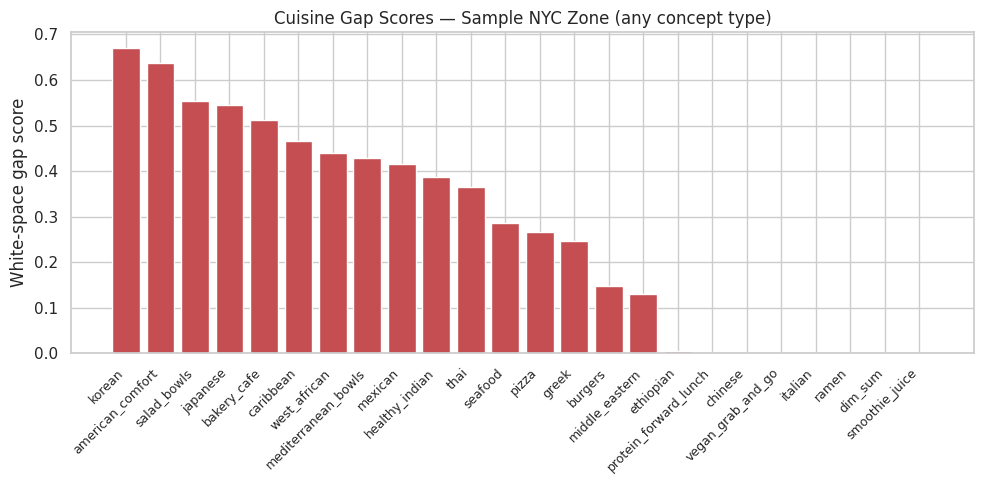

In [7]:
from src.nlp.white_space import compute_subtype_gap

# Simulate demand vs supply per subtype across a sample zone
rng2 = np.random.default_rng(7)
all_subtypes = list(all_known_subtypes())
demand = rng2.uniform(0.3, 0.9, size=len(all_subtypes))
supply = rng2.uniform(0.1, 0.7, size=len(all_subtypes))
gaps = [compute_subtype_gap(d, s) for d, s in zip(demand, supply)]

gap_df = pd.DataFrame(
    {"subtype": all_subtypes, "demand": demand, "supply": supply, "gap": gaps}
)
gap_df = gap_df.sort_values("gap", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(gap_df["subtype"], gap_df["gap"], color="#C44E52", edgecolor="white")
ax.set_xticklabels(gap_df["subtype"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("White-space gap score")
ax.set_title("Cuisine Gap Scores — Sample NYC Zone (any concept type)")
plt.tight_layout()
plt.show()

## Prompt Example


In [8]:
prompt = build_label_prompt(
    sample_reviews[0], ("healthy_indian", "ramen", "korean", "mexican")
)
print(prompt)

Label this Yelp review for halal food demand analysis.
Return JSON only with keys: sentiment, halal_relevance, concept_subtype, confidence.
sentiment must be one of: positive, neutral, negative.
halal_relevance must be one of: explicit_halal, implicit_halal, not_related.
The review text may include business context such as business name and categories. Use that context when judging halal relevance.
Use explicit_halal when the review text, business name, or business categories clearly mention halal.
Use implicit_halal only when the review implies halal demand, such as asking for more halal options or discussing a known halal concept.
Use not_related when halal demand is not clear. Be conservative and do not guess.
Allowed subtypes: healthy_indian, ramen, korean, mexican.
Do not create new concept_subtype labels. If none fit, use other.
Review: Amazing healthy Indian lunch bowl — fresh and light, will return.


## Summary

- The NLP pipeline supports any cuisine concept, not just healthy food.
- Without an API key, synthetic labels are produced for offline development.
- With `GEMINI_API_KEY` set, real Gemini 2.5 Flash Lite labels are generated.
- Zone-level `healthy_review_share` and `subtype_gap` feed directly into the CMF scoring layer.
- Gap scores vary dramatically by cuisine — some subtypes are heavily under-supplied.
